# Hierarchical ELBO VINDy for Parameter-Variational Vehicle Dynamics

This notebook implements the **ELBO-based version** of the parameter-variational VINDy idea.

Instead of fitting one pooled coefficient vector, each parameter-realization group has its own latent coefficient vector:

\[
\xi^{(r)} \sim p(\xi \mid \mu_\xi,\Sigma_\xi)
\]

\[
\dot X^{(r)} \sim \mathcal{N}\left(\Theta^{(r)}\xi^{(r)},\sigma_\epsilon^2 I\right)
\]

with a variational posterior:

\[
q_r(\xi^{(r)}) = \mathcal{N}(m_r,S_r)
\]

The optimized objective is the hierarchical ELBO:

\[
\mathcal{L}=
\sum_{r=1}^{N_r}
\left[
\mathbb{E}_{q_r}\log p(\dot X^{(r)}\mid \Theta^{(r)},\xi^{(r)})
-
\mathrm{KL}\left(q_r(\xi^{(r)})\|p(\xi\mid\mu_\xi,\Sigma_\xi)\right)
\right]
\]

Because the VINDy model is linear in the coefficients, the expected log-likelihood can be computed exactly. We optimize the variational parameters using PyTorch/Adam.

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================

from pathlib import Path
import json
import math
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError as e:
    raise ImportError(
        "PyTorch is required for this ELBO notebook. Install it with: pip install torch"
    ) from e

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use double precision for regression/ELBO stability.
torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Training settings
EPOCHS = 2000
LR = 3e-2
PRINT_EVERY = 200
GRAD_CLIP = 10.0

# ELBO settings
LEARN_GLOBAL_PRIOR = True      # learn mu_xi and Sigma_xi diagonal from data
LEARN_SIGMA_EPS = False        # usually safer to fix sigma_eps from group-wise residuals
Q_STD_FLOOR = 1e-5             # lower bound for q_r std in scaled-coefficient space
GLOBAL_STD_FLOOR = 1e-4        # lower bound for global prior std in scaled-coefficient space
SIGMA_EPS_FLOOR = 1e-4         # lower bound for noise std in scaled target space
RIDGE_INIT = 1e-8              # ridge used only for LS initialization

# Numerical clipping for plots/coverage
EPS = 1e-12

Using device: cpu


## 1. Load dataset

The notebook expects the rich-excitation VINDy dataset generated by your data-generation script. It uses:

\[
X = [v_x, v_y, \omega, \alpha_f, \alpha_r]
\]

\[
U = [\delta, T_r]
\]

\[
\dot X = [\dot v_x, \dot v_y, \dot\omega]
\]

The grouping variable should identify which samples came from the same parameter realization. The preferred key is `train_param_id`, then `train_traj_id`, then `train_run_id`.

In [2]:
# ============================================================
# 1. Load data
# ============================================================

DATA_PATH_CANDIDATES = [
    Path("Data/vindy_data_rich_excitation.npz"),
    Path("../Data/vindy_data_rich_excitation.npz"),
    Path("./vindy_data_rich_excitation.npz"),
    Path("/mnt/data/Data/vindy_data_rich_excitation.npz"),
    Path("/mnt/data/vindy_data_rich_excitation.npz"),
]

DATA_PATH = None
for p in DATA_PATH_CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find vindy_data_rich_excitation.npz. "
        "Put it in ./Data/ or update DATA_PATH manually."
    )

print("Loading:", DATA_PATH)
data = np.load(DATA_PATH, allow_pickle=True)
print("Available keys:")
print(sorted(list(data.files)))

# Required arrays
X_train = data["X_train"]
U_train = data["U_train"]
Xd_train = data["Xd_train"]

X_val = data["X_val"] if "X_val" in data.files else None
U_val = data["U_val"] if "U_val" in data.files else None
Xd_val = data["Xd_val"] if "Xd_val" in data.files else None

X_test = data["X_test"] if "X_test" in data.files else None
U_test = data["U_test"] if "U_test" in data.files else None
Xd_test = data["Xd_test"] if "Xd_test" in data.files else None

print("\nShapes:")
print("  X_train:", X_train.shape)
print("  U_train:", U_train.shape)
print("  Xd_train:", Xd_train.shape)
if X_val is not None:
    print("  X_val:  ", X_val.shape)
if X_test is not None:
    print("  X_test: ", X_test.shape)

channel_names = ["vx_dot", "vy_dot", "omega_dot"]


def pick_group_key(split, data):
    candidates = [
        f"{split}_param_id",
        f"{split}_traj_id",
        f"{split}_run_id",
        f"{split}_group_id",
        f"{split}_window_id",
    ]
    for k in candidates:
        if k in data.files:
            return k
    raise KeyError(
        f"No group id key found for split='{split}'. "
        f"Expected one of: {candidates}. "
        "Update the generator to save per-sample group IDs."
    )

train_group_key = pick_group_key("train", data)
train_groups = data[train_group_key].astype(int)
print("\nUsing train group key:", train_group_key)
print("Unique train groups:", len(np.unique(train_groups)))

val_groups = None
test_groups = None
if X_val is not None:
    val_group_key = pick_group_key("val", data)
    val_groups = data[val_group_key].astype(int)
    print("Using val group key:", val_group_key)
    print("Unique val groups:", len(np.unique(val_groups)))

if X_test is not None:
    test_group_key = pick_group_key("test", data)
    test_groups = data[test_group_key].astype(int)
    print("Using test group key:", test_group_key)
    print("Unique test groups:", len(np.unique(test_groups)))

Loading: Data\vindy_data_rich_excitation.npz
Available keys:
['U_test', 'U_train', 'U_val', 'X_test', 'X_train', 'X_val', 'Xd_test', 'Xd_train', 'Xd_val', 'nom_B_f', 'nom_B_r', 'nom_C_f', 'nom_C_r', 'nom_D_f', 'nom_D_r', 'nom_E_f', 'nom_E_r', 'nom_Jz', 'nom_M', 'nom_R_wheel', 'nom_lf', 'nom_lr', 'ptest_B_f', 'ptest_B_r', 'ptest_C_f', 'ptest_C_r', 'ptest_D_f', 'ptest_D_r', 'ptest_E_f', 'ptest_E_r', 'ptest_Jz', 'ptest_M', 'ptest_lf', 'ptest_lr', 'ptrain_B_f', 'ptrain_B_r', 'ptrain_C_f', 'ptrain_C_r', 'ptrain_D_f', 'ptrain_D_r', 'ptrain_E_f', 'ptrain_E_r', 'ptrain_Jz', 'ptrain_M', 'ptrain_lf', 'ptrain_lr', 'pval_B_f', 'pval_B_r', 'pval_C_f', 'pval_C_r', 'pval_D_f', 'pval_D_r', 'pval_E_f', 'pval_E_r', 'pval_Jz', 'pval_M', 'pval_lf', 'pval_lr', 'test_L_straight', 'test_R_turn', 'test_T_exc', 'test_delta_exc', 'test_laps', 'test_param_id', 'test_run_id', 'test_sim_duration', 'test_t', 'test_traj_id', 'test_v_base', 'test_v_ref', 'test_window_score', 'train_L_straight', 'train_R_turn', 'train

## 2. Build the reduced physics-informed library

The reduced library avoids the highly collinear seventh- and ninth-order slip terms and keeps the terms needed to represent the vehicle dynamics.

In [3]:
# ============================================================
# 2. Reduced VINDy library
# ============================================================

def build_vehicle_library(X, U):
    """
    X columns: [vx, vy, omega, alpha_f, alpha_r]
    U columns: [delta, Tr]
    """
    vx = X[:, 0]
    vy = X[:, 1]
    omega = X[:, 2]
    af = X[:, 3]
    ar = X[:, 4]

    delta = U[:, 0]
    Tr = U[:, 1]

    s = np.sin(delta)
    c = np.cos(delta)

    Theta = np.column_stack([
        omega * vy,          # 0
        omega * vx,          # 1
        vx,                  # 2
        vy,                  # 3
        Tr,                  # 4
        delta,               # 5
        af * s,              # 6
        af * c,              # 7
        af**3 * s,           # 8
        af**3 * c,           # 9
        af**5 * s,           # 10
        af**5 * c,           # 11
        ar,                  # 12
        ar**3,               # 13
        ar**5,               # 14
        vx * af * c,         # 15
        vx * ar,             # 16
    ])

    terms = [
        "omega*vy",
        "omega*vx",
        "vx",
        "vy",
        "Tr",
        "delta",
        "af*sin(d)",
        "af*cos(d)",
        "af^3*sin(d)",
        "af^3*cos(d)",
        "af^5*sin(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
        "vx*af*cos(d)",
        "vx*ar",
    ]

    return Theta, terms

Theta_train_raw, terms = build_vehicle_library(X_train, U_train)
Theta_val_raw = build_vehicle_library(X_val, U_val)[0] if X_val is not None else None
Theta_test_raw = build_vehicle_library(X_test, U_test)[0] if X_test is not None else None

print("Theta_train shape:", Theta_train_raw.shape)
print("Terms:")
for i, t in enumerate(terms):
    print(f"  [{i:2d}] {t}")

assert len(terms) == 17
assert all("af^7" not in t for t in terms)
assert all("af^9" not in t for t in terms)
assert all("ar^7" not in t for t in terms)
assert all("ar^9" not in t for t in terms)
print("\n✅ Reduced 17-term library is active.")

Theta_train shape: (352751, 17)
Terms:
  [ 0] omega*vy
  [ 1] omega*vx
  [ 2] vx
  [ 3] vy
  [ 4] Tr
  [ 5] delta
  [ 6] af*sin(d)
  [ 7] af*cos(d)
  [ 8] af^3*sin(d)
  [ 9] af^3*cos(d)
  [10] af^5*sin(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5
  [15] vx*af*cos(d)
  [16] vx*ar

✅ Reduced 17-term library is active.


## 3. Channel-specific active libraries

The hierarchical ELBO is applied to channel-specific physical libraries. This prevents unphysical compensation terms from entering every equation.

In [4]:
# ============================================================
# 3. Channel-specific active terms
# ============================================================

active_terms_by_channel = {
    "vx_dot": [
        "omega*vy",
        "Tr",
        "af*sin(d)",
        "af^3*sin(d)",
        "af^5*sin(d)",
    ],

    "vy_dot": [
        "omega*vx",
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],

    "omega_dot": [
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],
}

term_to_idx = {t: i for i, t in enumerate(terms)}
active_idx_by_channel = {
    ch: np.array([term_to_idx[t] for t in active_terms], dtype=int)
    for ch, active_terms in active_terms_by_channel.items()
}

for ch in channel_names:
    print(f"\n{ch} active terms:")
    for idx in active_idx_by_channel[ch]:
        print(f"  [{idx:2d}] {terms[idx]}")


vx_dot active terms:
  [ 0] omega*vy
  [ 4] Tr
  [ 6] af*sin(d)
  [ 8] af^3*sin(d)
  [10] af^5*sin(d)

vy_dot active terms:
  [ 1] omega*vx
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5

omega_dot active terms:
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5


## 4. Scaling

The ELBO is optimized in a scaled coefficient space for numerical stability. Raw coefficients are recovered after training.

If
\[
\Theta_s = \Theta / s_\Theta, \qquad y_s = y/s_y,
\]
then
\[
\xi_{\text{raw},j} = \frac{s_y}{s_{\Theta,j}}\xi_{s,j}.
\]

In [5]:
# ============================================================
# 4. Scaling
# ============================================================

# Library RMS scale computed on training data.
theta_scale = np.sqrt(np.mean(Theta_train_raw**2, axis=0))
theta_scale = np.where(theta_scale < 1e-12, 1.0, theta_scale)

Theta_train = Theta_train_raw / theta_scale
Theta_val = Theta_val_raw / theta_scale if Theta_val_raw is not None else None
Theta_test = Theta_test_raw / theta_scale if Theta_test_raw is not None else None

# Target scale per channel computed on training data.
y_scale = np.std(Xd_train, axis=0)
y_scale = np.where(y_scale < 1e-12, 1.0, y_scale)

Xd_train_s = Xd_train / y_scale
Xd_val_s = Xd_val / y_scale if Xd_val is not None else None
Xd_test_s = Xd_test / y_scale if Xd_test is not None else None

print("theta_scale:")
for i, t in enumerate(terms):
    print(f"  {t:20s}: {theta_scale[i]:.6g}")
print("\ny_scale:", dict(zip(channel_names, y_scale)))

theta_scale:
  omega*vy            : 0.173902
  omega*vx            : 4.61367
  vx                  : 20.0247
  vy                  : 0.56157
  Tr                  : 640.122
  delta               : 0.0820676
  af*sin(d)           : 0.0151494
  af*cos(d)           : 0.0885592
  af^3*sin(d)         : 0.00109195
  af^3*cos(d)         : 0.00434692
  af^5*sin(d)         : 0.000101498
  af^5*cos(d)         : 0.000364854
  ar                  : 0.0378297
  ar^3                : 0.000187924
  ar^5                : 1.45404e-06
  vx*af*cos(d)        : 2.14682
  vx*ar               : 0.889777

y_scale: {'vx_dot': np.float64(1.304683137862106), 'vy_dot': np.float64(0.6915174472308908), 'omega_dot': np.float64(0.37730489968082975)}


## 5. Group statistics for exact expected log-likelihood

For each group and channel, the ELBO uses sufficient statistics:

\[
A_r = (\Theta^{(r)})^T\Theta^{(r)}, \qquad
b_r = (\Theta^{(r)})^T y^{(r)}, \qquad
y_r^T y_r.
\]

This avoids repeatedly looping over all samples during ELBO optimization.

In [6]:
# ============================================================
# 5. Group utilities and sufficient statistics
# ============================================================

def unique_group_mapping(groups):
    unique = np.unique(groups)
    group_to_pos = {g: i for i, g in enumerate(unique)}
    pos = np.array([group_to_pos[g] for g in groups], dtype=int)
    return unique, pos, group_to_pos


def compute_group_stats(Theta_s, y_s, groups, active_idx):
    """
    Computes A_r, b_r, yty_r, n_r for each group in scaled units.
    """
    unique, _, _ = unique_group_mapping(groups)
    G = len(unique)
    p = len(active_idx)

    A = np.zeros((G, p, p), dtype=np.float64)
    b = np.zeros((G, p), dtype=np.float64)
    yty = np.zeros(G, dtype=np.float64)
    n = np.zeros(G, dtype=np.float64)

    for gi, g in enumerate(unique):
        mask = groups == g
        Th = Theta_s[mask][:, active_idx]
        y = y_s[mask]
        A[gi] = Th.T @ Th
        b[gi] = Th.T @ y
        yty[gi] = float(y @ y)
        n[gi] = float(len(y))

    return {
        "unique_groups": unique,
        "A": A,
        "b": b,
        "yty": yty,
        "n": n,
    }


def fit_group_ridge_initialization(Theta_s, y_s, groups, active_idx, ridge=RIDGE_INIT):
    """
    Ridge/least-squares group-wise initialization in scaled units.
    Returns B: [n_groups, n_active].
    """
    stats = compute_group_stats(Theta_s, y_s, groups, active_idx)
    A, b = stats["A"], stats["b"]
    G, p, _ = A.shape

    B = np.zeros((G, p), dtype=np.float64)
    for g in range(G):
        B[g] = np.linalg.solve(A[g] + ridge * np.eye(p), b[g])

    return B, stats


def residual_sigma_from_group_fit(Theta_s, y_s, groups, active_idx, B_group, unique_groups):
    """
    Estimate scaled sigma_epsilon from group-wise posterior/LS mean residuals.
    """
    group_to_pos = {g: i for i, g in enumerate(unique_groups)}
    pred = np.zeros_like(y_s)
    for g in unique_groups:
        mask = groups == g
        gi = group_to_pos[g]
        pred[mask] = Theta_s[mask][:, active_idx] @ B_group[gi]
    resid = y_s - pred
    dof = max(len(y_s) - B_group.size, 1)
    return float(np.sqrt(np.sum(resid**2) / dof)), resid

## 6. Hierarchical ELBO model

For one channel, the variational posterior is:

\[
q_r(\xi^{(r)}) = \mathcal{N}(m_r,\mathrm{diag}(s_r^2)).
\]

The global prior is diagonal Gaussian:

\[
p(\xi^{(r)}\mid \mu_\xi,\tau_\xi) = \mathcal{N}(\mu_\xi,\mathrm{diag}(\tau_\xi^2)).
\]

The expected squared error under \(q_r\) is:

\[
\mathbb{E}_{q_r}\|y_r-\Theta_r\xi_r\|^2
=
y_r^Ty_r - 2m_r^Tb_r + m_r^TA_rm_r + \mathrm{tr}(A_rS_r).
\]

In [7]:
# ============================================================
# 6. PyTorch hierarchical ELBO model
# ============================================================

def inv_softplus_np(y):
    y = np.asarray(y, dtype=np.float64)
    return np.where(y > 30.0, y, np.log(np.expm1(np.maximum(y, 1e-12))))


class HierarchicalVINDyChannel(nn.Module):
    def __init__(
        self,
        m_init,
        q_std_init,
        global_mu_init,
        global_std_init,
        sigma_eps_init,
        learn_global_prior=True,
        learn_sigma_eps=False,
    ):
        super().__init__()
        m_init = np.asarray(m_init, dtype=np.float64)
        q_std_init = np.asarray(q_std_init, dtype=np.float64)
        global_mu_init = np.asarray(global_mu_init, dtype=np.float64)
        global_std_init = np.asarray(global_std_init, dtype=np.float64)

        self.m = nn.Parameter(torch.tensor(m_init, device=DEVICE))
        self.q_rho = nn.Parameter(torch.tensor(inv_softplus_np(q_std_init - Q_STD_FLOOR), device=DEVICE))

        if learn_global_prior:
            self.global_mu = nn.Parameter(torch.tensor(global_mu_init, device=DEVICE))
            self.global_rho = nn.Parameter(torch.tensor(inv_softplus_np(global_std_init - GLOBAL_STD_FLOOR), device=DEVICE))
        else:
            self.register_buffer("global_mu", torch.tensor(global_mu_init, device=DEVICE))
            self.register_buffer("global_rho", torch.tensor(inv_softplus_np(global_std_init - GLOBAL_STD_FLOOR), device=DEVICE))

        if learn_sigma_eps:
            self.noise_rho = nn.Parameter(torch.tensor(float(inv_softplus_np(sigma_eps_init - SIGMA_EPS_FLOOR)), device=DEVICE))
        else:
            self.register_buffer("noise_rho", torch.tensor(float(inv_softplus_np(sigma_eps_init - SIGMA_EPS_FLOOR)), device=DEVICE))

    def q_std(self):
        return F.softplus(self.q_rho) + Q_STD_FLOOR

    def global_std(self):
        return F.softplus(self.global_rho) + GLOBAL_STD_FLOOR

    def sigma_eps(self):
        return F.softplus(self.noise_rho) + SIGMA_EPS_FLOOR

    def neg_elbo(self, A, b, yty, n):
        """
        Negative ELBO for one channel using group sufficient statistics.
        A: [G,p,p]
        b: [G,p]
        yty: [G]
        n: [G]
        """
        m = self.m
        s = self.q_std()
        var = s**2
        mu0 = self.global_mu
        tau = self.global_std()
        sigma = self.sigma_eps()

        # Expected SSE per group:
        # yty - 2 m^T b + m^T A m + tr(A diag(var))
        mAm = torch.einsum("gp,gpq,gq->g", m, A, m)
        mb = torch.sum(m * b, dim=1)
        trace_term = torch.sum(torch.diagonal(A, dim1=1, dim2=2) * var, dim=1)
        expected_sse = yty - 2.0 * mb + mAm + trace_term

        # Negative expected log likelihood, constants included.
        nll = 0.5 * torch.sum(expected_sse / (sigma**2) + n * torch.log(2.0 * torch.pi * sigma**2))

        # KL(q_r || p_global), summed over groups and coefficients.
        # KL = 0.5 * [log(tau^2/s^2) + (s^2 + (m-mu)^2)/tau^2 - 1]
        kl_terms = torch.log(tau / s) + 0.5 * (var + (m - mu0)**2) / (tau**2) - 0.5
        kl = torch.sum(kl_terms)

        return nll + kl, {"nll": nll.detach(), "kl": kl.detach(), "sigma": sigma.detach()}

## 7. Train the hierarchical ELBO model

The next cell trains one hierarchical ELBO model per derivative channel. The same group IDs are used for all channels, so sampled scenarios can preserve joint group consistency.

In [8]:
# ============================================================
# 7. Train one hierarchical model per channel
# ============================================================

models = {}
train_stats_by_channel = {}
init_group_B_by_channel = {}
history_by_channel = {}

for ch_idx, ch in enumerate(channel_names):
    print("\n" + "="*80)
    print(f"Training hierarchical ELBO VINDy channel: {ch}")
    print("="*80)

    active_idx = active_idx_by_channel[ch]
    y_s = Xd_train_s[:, ch_idx]

    # Group-wise LS initialization in scaled units.
    B0, stats = fit_group_ridge_initialization(
        Theta_s=Theta_train,
        y_s=y_s,
        groups=train_groups,
        active_idx=active_idx,
        ridge=RIDGE_INIT,
    )

    sigma_eps_init, init_resid = residual_sigma_from_group_fit(
        Theta_s=Theta_train,
        y_s=y_s,
        groups=train_groups,
        active_idx=active_idx,
        B_group=B0,
        unique_groups=stats["unique_groups"],
    )
    sigma_eps_init = max(float(sigma_eps_init), SIGMA_EPS_FLOOR * 10.0)

    # Initialize q std as a small fraction of empirical coefficient spread.
    empirical_std = np.std(B0, axis=0) + 1e-3
    q_std_init = np.tile(0.05 * empirical_std[None, :], (B0.shape[0], 1))
    q_std_init = np.maximum(q_std_init, Q_STD_FLOOR * 10.0)

    global_mu_init = np.mean(B0, axis=0)
    global_std_init = np.std(B0, axis=0) + 1e-3
    global_std_init = np.maximum(global_std_init, GLOBAL_STD_FLOOR * 10.0)

    model = HierarchicalVINDyChannel(
        m_init=B0,
        q_std_init=q_std_init,
        global_mu_init=global_mu_init,
        global_std_init=global_std_init,
        sigma_eps_init=sigma_eps_init,
        learn_global_prior=LEARN_GLOBAL_PRIOR,
        learn_sigma_eps=LEARN_SIGMA_EPS,
    ).to(DEVICE)

    A_t = torch.tensor(stats["A"], device=DEVICE)
    b_t = torch.tensor(stats["b"], device=DEVICE)
    yty_t = torch.tensor(stats["yty"], device=DEVICE)
    n_t = torch.tensor(stats["n"], device=DEVICE)
    n_total = float(np.sum(stats["n"]))

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    hist = {"loss": [], "nll": [], "kl": [], "sigma": []}

    for epoch in range(1, EPOCHS + 1):
        optimizer.zero_grad()
        neg_elbo, parts = model.neg_elbo(A_t, b_t, yty_t, n_t)

        # Normalize by number of samples for stable gradient magnitudes.
        loss = neg_elbo / n_total
        loss.backward()
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        hist["loss"].append(float(loss.detach().cpu()))
        hist["nll"].append(float((parts["nll"] / n_total).cpu()))
        hist["kl"].append(float((parts["kl"] / n_total).cpu()))
        hist["sigma"].append(float(parts["sigma"].cpu()))

        if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
            print(
                f"epoch {epoch:5d}/{EPOCHS} | "
                f"loss={hist['loss'][-1]:+.6e} | "
                f"nll={hist['nll'][-1]:+.6e} | "
                f"kl={hist['kl'][-1]:+.6e} | "
                f"sigma_eps_scaled={hist['sigma'][-1]:.6f}"
            )

    models[ch] = model
    train_stats_by_channel[ch] = stats
    init_group_B_by_channel[ch] = B0
    history_by_channel[ch] = hist


Training hierarchical ELBO VINDy channel: vx_dot
epoch     1/2000 | loss=+9.149610e-01 | nll=+9.099844e-01 | kl=+4.976560e-03 | sigma_eps_scaled=0.002599
epoch   200/2000 | loss=-8.455330e-01 | nll=-8.524961e-01 | kl=+6.963055e-03 | sigma_eps_scaled=0.002599
epoch   400/2000 | loss=-2.535043e+00 | nll=-2.542409e+00 | kl=+7.365790e-03 | sigma_eps_scaled=0.002599
epoch   600/2000 | loss=-3.377026e+00 | nll=-3.384825e+00 | kl=+7.799226e-03 | sigma_eps_scaled=0.002599
epoch   800/2000 | loss=-2.000947e+00 | nll=-2.009130e+00 | kl=+8.182522e-03 | sigma_eps_scaled=0.002599
epoch  1000/2000 | loss=-1.220454e+00 | nll=-1.228778e+00 | kl=+8.323582e-03 | sigma_eps_scaled=0.002599
epoch  1200/2000 | loss=-2.619475e+00 | nll=-2.627919e+00 | kl=+8.443425e-03 | sigma_eps_scaled=0.002599
epoch  1400/2000 | loss=-2.893470e+00 | nll=-2.902185e+00 | kl=+8.715057e-03 | sigma_eps_scaled=0.002599
epoch  1600/2000 | loss=-2.353484e+00 | nll=-2.362281e+00 | kl=+8.796720e-03 | sigma_eps_scaled=0.002599
epoch

## 8. Extract raw coefficients

The trained parameters are in scaled units. This cell converts group posterior means/stds and global prior means/stds back to raw VINDy coefficients.

In [9]:
# ============================================================
# 8. Extract raw coefficients
# ============================================================

def active_scaled_to_full_raw(B_scaled_active, active_idx, ch_idx):
    """
    Convert active scaled coefficients to full raw coefficient vectors.
    B_scaled_active shape: [G,p] or [p]
    """
    B = np.asarray(B_scaled_active)
    one_dim = (B.ndim == 1)
    if one_dim:
        B = B[None, :]

    out = np.zeros((B.shape[0], len(terms)), dtype=np.float64)
    conversion = y_scale[ch_idx] / theta_scale[active_idx]
    out[:, active_idx] = B * conversion[None, :]

    return out[0] if one_dim else out


def extract_channel_params(ch, ch_idx):
    model = models[ch]
    active_idx = active_idx_by_channel[ch]
    with torch.no_grad():
        m_scaled = model.m.detach().cpu().numpy()
        s_scaled = model.q_std().detach().cpu().numpy()
        mu_scaled = model.global_mu.detach().cpu().numpy()
        tau_scaled = model.global_std().detach().cpu().numpy()
        sigma_eps_scaled = float(model.sigma_eps().detach().cpu().numpy())

    group_mu_raw = active_scaled_to_full_raw(m_scaled, active_idx, ch_idx)
    group_std_raw = active_scaled_to_full_raw(s_scaled, active_idx, ch_idx)
    global_mu_raw = active_scaled_to_full_raw(mu_scaled, active_idx, ch_idx)
    global_std_raw = active_scaled_to_full_raw(tau_scaled, active_idx, ch_idx)
    sigma_eps_raw = sigma_eps_scaled * y_scale[ch_idx]

    return {
        "m_scaled": m_scaled,
        "s_scaled": s_scaled,
        "mu_scaled": mu_scaled,
        "tau_scaled": tau_scaled,
        "sigma_eps_scaled": sigma_eps_scaled,
        "group_mu_raw": group_mu_raw,
        "group_std_raw": group_std_raw,
        "global_mu_raw": global_mu_raw,
        "global_std_raw": global_std_raw,
        "sigma_eps_raw": sigma_eps_raw,
    }

params_by_channel = {
    ch: extract_channel_params(ch, i)
    for i, ch in enumerate(channel_names)
}

for ch in channel_names:
    print("\n" + "="*70)
    print(ch)
    print("="*70)
    active_idx = active_idx_by_channel[ch]
    p = params_by_channel[ch]
    for idx in active_idx:
        print(
            f"{terms[idx]:20s} "
            f"global_mu_raw={p['global_mu_raw'][idx]:+12.6f}  "
            f"global_std_raw={p['global_std_raw'][idx]:10.6f}"
        )
    print(f"sigma_eps_raw = {p['sigma_eps_raw']:.6f}")


vx_dot
omega*vy             global_mu_raw=   +0.978027  global_std_raw=  0.022068
Tr                   global_mu_raw=   +0.002194  global_std_raw=  0.000191
af*sin(d)            global_mu_raw=  -43.651778  global_std_raw=  6.428652
af^3*sin(d)          global_mu_raw= +421.991815  global_std_raw= 86.646475
af^5*sin(d)          global_mu_raw=-1474.727025  global_std_raw=1173.569422
sigma_eps_raw = 0.003390

vy_dot
omega*vx             global_mu_raw=   -0.996905  global_std_raw=  0.001492
af*cos(d)            global_mu_raw=  +43.072227  global_std_raw=  6.371311
af^3*cos(d)          global_mu_raw= -405.611227  global_std_raw= 86.054137
af^5*cos(d)          global_mu_raw=+1434.421185  global_std_raw=1009.693330
ar                   global_mu_raw=  +40.886441  global_std_raw=  5.497601
ar^3                 global_mu_raw=+2093.368003  global_std_raw=1285.779228
ar^5                 global_mu_raw=-482653.522429  global_std_raw=480721.660831
sigma_eps_raw = 0.015986

omega_dot
af*cos(d)      

## 9. Evaluation utilities

In [10]:
# ============================================================
# 9. Evaluation utilities
# ============================================================

def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    bias = np.mean(err)
    nrmse = rmse / (np.std(y_true) + EPS)
    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) + EPS
    r2 = 1.0 - ss_res / ss_tot
    return rmse, mae, bias, nrmse, r2


def print_metric_table(name, Y_true, Y_pred):
    print("\n" + "="*72)
    print(name)
    print("="*72)
    for j, ch in enumerate(channel_names):
        rmse, mae, bias, nrmse, r2 = regression_metrics(Y_true[:, j], Y_pred[:, j])
        status = "PASS" if r2 > 0.90 else "FAIL"
        print(
            f"{ch:10s} | RMSE={rmse:10.5f} | NRMSE={nrmse:8.4f} | "
            f"Bias={bias:+10.5f} | R²={r2:9.6f} | {status}"
        )


def predict_with_global_mean(Theta_raw, params_by_channel):
    Y = np.zeros((Theta_raw.shape[0], len(channel_names)))
    for j, ch in enumerate(channel_names):
        Y[:, j] = Theta_raw @ params_by_channel[ch]["global_mu_raw"]
    return Y


def predict_with_group_means(Theta_raw, groups, unique_groups, group_mu_raw_by_channel):
    Y = np.zeros((Theta_raw.shape[0], len(channel_names)))
    group_to_pos = {g: i for i, g in enumerate(unique_groups)}
    for g in unique_groups:
        mask = groups == g
        gi = group_to_pos[g]
        for j, ch in enumerate(channel_names):
            Y[mask, j] = Theta_raw[mask] @ group_mu_raw_by_channel[ch][gi]
    return Y


def fit_pooled_ls(Theta_s, Xd_s, active_idx_by_channel):
    """Pooled baseline in scaled units, converted to raw full coefficients."""
    out_raw = {}
    for j, ch in enumerate(channel_names):
        idx = active_idx_by_channel[ch]
        beta_s, *_ = np.linalg.lstsq(Theta_s[:, idx], Xd_s[:, j], rcond=None)
        out_raw[ch] = active_scaled_to_full_raw(beta_s, idx, j)
    return out_raw


def predict_with_coeff_dict(Theta_raw, coeff_dict):
    Y = np.zeros((Theta_raw.shape[0], len(channel_names)))
    for j, ch in enumerate(channel_names):
        Y[:, j] = Theta_raw @ coeff_dict[ch]
    return Y

## 10. Baselines and train evaluation

This cell compares:

1. pooled deterministic baseline;
2. global prior mean from the hierarchical ELBO;
3. train group posterior means from the hierarchical ELBO.

In [11]:
# ============================================================
# 10. Baseline and train evaluation
# ============================================================

# Pooled deterministic baseline using the same active terms.
pooled_coeff_raw = fit_pooled_ls(Theta_train, Xd_train_s, active_idx_by_channel)

Xd_train_pred_pooled = predict_with_coeff_dict(Theta_train_raw, pooled_coeff_raw)
Xd_train_pred_global_mean = predict_with_global_mean(Theta_train_raw, params_by_channel)

# Train group posterior mean prediction.
train_unique_groups = train_stats_by_channel[channel_names[0]]["unique_groups"]
train_group_mu_raw_by_channel = {
    ch: params_by_channel[ch]["group_mu_raw"]
    for ch in channel_names
}
Xd_train_pred_group_post = predict_with_group_means(
    Theta_raw=Theta_train_raw,
    groups=train_groups,
    unique_groups=train_unique_groups,
    group_mu_raw_by_channel=train_group_mu_raw_by_channel,
)

print_metric_table("TRAIN — pooled deterministic baseline", Xd_train, Xd_train_pred_pooled)
print_metric_table("TRAIN — hierarchical global prior mean only", Xd_train, Xd_train_pred_global_mean)
print_metric_table("TRAIN — hierarchical group posterior means", Xd_train, Xd_train_pred_group_post)


TRAIN — pooled deterministic baseline
vx_dot     | RMSE=   0.11565 | NRMSE=  0.0886 | Bias=  -0.00167 | R²= 0.992143 | PASS
vy_dot     | RMSE=   0.39890 | NRMSE=  0.5768 | Bias=  +0.02387 | R²= 0.667255 | FAIL
omega_dot  | RMSE=   0.24379 | NRMSE=  0.6461 | Bias=  +0.00716 | R²= 0.582509 | FAIL

TRAIN — hierarchical global prior mean only
vx_dot     | RMSE=   0.11933 | NRMSE=  0.0915 | Bias=  -0.00292 | R²= 0.991635 | PASS
vy_dot     | RMSE=   0.62071 | NRMSE=  0.8976 | Bias=  +0.06348 | R²= 0.194294 | FAIL
omega_dot  | RMSE=   0.68388 | NRMSE=  1.8125 | Bias=  +0.09034 | R²=-2.285268 | FAIL

TRAIN — hierarchical group posterior means
vx_dot     | RMSE=   0.00796 | NRMSE=  0.0061 | Bias=  -0.00031 | R²= 0.999963 | PASS
vy_dot     | RMSE=   0.01634 | NRMSE=  0.0236 | Bias=  +0.00032 | R²= 0.999442 | PASS
omega_dot  | RMSE=   0.01516 | NRMSE=  0.0402 | Bias=  -0.00057 | R²= 0.998386 | PASS


## 11. Closed-form inference for validation/test groups under the learned global prior

For new observed groups, the optimal Gaussian posterior under the learned global prior has a closed form because the model is linear-Gaussian. This is still the same ELBO solution, but computed analytically for held-out groups after the global prior has been learned from training groups.

In [12]:
# ============================================================
# 11. Closed-form posterior inference for new groups
# ============================================================

def infer_group_posteriors_closed_form(Theta_s, Xd_s, groups, split_name):
    """
    Infer q_r(xi_r) for each group in a split using the learned global prior.
    Returns raw full coefficient means/stds by channel and unique group IDs.
    """
    out_mu_raw = {}
    out_std_raw = {}
    unique_ref = None

    for j, ch in enumerate(channel_names):
        active_idx = active_idx_by_channel[ch]
        stats = compute_group_stats(Theta_s, Xd_s[:, j], groups, active_idx)
        unique = stats["unique_groups"]
        if unique_ref is None:
            unique_ref = unique
        else:
            assert np.array_equal(unique_ref, unique), "Group IDs must align across channels."

        A = stats["A"]
        b = stats["b"]
        G, p, _ = A.shape

        prior_mu = params_by_channel[ch]["mu_scaled"]
        prior_tau = params_by_channel[ch]["tau_scaled"]
        sigma = params_by_channel[ch]["sigma_eps_scaled"]

        prior_precision = np.diag(1.0 / (prior_tau**2 + EPS))
        prior_rhs = prior_mu / (prior_tau**2 + EPS)

        m = np.zeros((G, p))
        s = np.zeros((G, p))

        for gi in range(G):
            Precision = A[gi] / (sigma**2 + EPS) + prior_precision
            rhs = b[gi] / (sigma**2 + EPS) + prior_rhs
            Cov = np.linalg.inv(Precision)
            m[gi] = Cov @ rhs
            s[gi] = np.sqrt(np.maximum(np.diag(Cov), 0.0))

        out_mu_raw[ch] = active_scaled_to_full_raw(m, active_idx, j)
        out_std_raw[ch] = active_scaled_to_full_raw(s, active_idx, j)

    print(f"{split_name}: inferred posteriors for {len(unique_ref)} groups.")
    return unique_ref, out_mu_raw, out_std_raw


# Validation/test inference if available.
if X_val is not None:
    val_unique_groups, val_group_mu_raw_by_channel, val_group_std_raw_by_channel = infer_group_posteriors_closed_form(
        Theta_s=Theta_val,
        Xd_s=Xd_val_s,
        groups=val_groups,
        split_name="VAL",
    )
    Xd_val_pred_group_post = predict_with_group_means(
        Theta_raw=Theta_val_raw,
        groups=val_groups,
        unique_groups=val_unique_groups,
        group_mu_raw_by_channel=val_group_mu_raw_by_channel,
    )
    Xd_val_pred_global_mean = predict_with_global_mean(Theta_val_raw, params_by_channel)
    Xd_val_pred_pooled = predict_with_coeff_dict(Theta_val_raw, pooled_coeff_raw)

    print_metric_table("VAL — pooled deterministic baseline", Xd_val, Xd_val_pred_pooled)
    print_metric_table("VAL — hierarchical global prior mean only", Xd_val, Xd_val_pred_global_mean)
    print_metric_table("VAL — inferred group posteriors under learned prior", Xd_val, Xd_val_pred_group_post)

if X_test is not None:
    test_unique_groups, test_group_mu_raw_by_channel, test_group_std_raw_by_channel = infer_group_posteriors_closed_form(
        Theta_s=Theta_test,
        Xd_s=Xd_test_s,
        groups=test_groups,
        split_name="TEST",
    )
    Xd_test_pred_group_post = predict_with_group_means(
        Theta_raw=Theta_test_raw,
        groups=test_groups,
        unique_groups=test_unique_groups,
        group_mu_raw_by_channel=test_group_mu_raw_by_channel,
    )
    Xd_test_pred_global_mean = predict_with_global_mean(Theta_test_raw, params_by_channel)
    Xd_test_pred_pooled = predict_with_coeff_dict(Theta_test_raw, pooled_coeff_raw)

    print_metric_table("TEST — pooled deterministic baseline", Xd_test, Xd_test_pred_pooled)
    print_metric_table("TEST — hierarchical global prior mean only", Xd_test, Xd_test_pred_global_mean)
    print_metric_table("TEST — inferred group posteriors under learned prior", Xd_test, Xd_test_pred_group_post)

VAL: inferred posteriors for 8 groups.

VAL — pooled deterministic baseline
vx_dot     | RMSE=   0.11543 | NRMSE=  0.0884 | Bias=  +0.00488 | R²= 0.992181 | PASS
vy_dot     | RMSE=   0.41503 | NRMSE=  0.5715 | Bias=  -0.03580 | R²= 0.673439 | FAIL
omega_dot  | RMSE=   0.24458 | NRMSE=  0.6028 | Bias=  +0.02112 | R²= 0.636573 | FAIL

VAL — hierarchical global prior mean only
vx_dot     | RMSE=   0.11420 | NRMSE=  0.0875 | Bias=  +0.00367 | R²= 0.992348 | PASS
vy_dot     | RMSE=   0.66162 | NRMSE=  0.9110 | Bias=  -0.05055 | R²= 0.170105 | FAIL
omega_dot  | RMSE=   0.54295 | NRMSE=  1.3383 | Bias=  +0.08835 | R²=-0.790974 | FAIL

VAL — inferred group posteriors under learned prior
vx_dot     | RMSE=   0.00154 | NRMSE=  0.0012 | Bias=  +0.00041 | R²= 0.999999 | PASS
vy_dot     | RMSE=   0.01128 | NRMSE=  0.0155 | Bias=  -0.00038 | R²= 0.999759 | PASS
omega_dot  | RMSE=   0.01043 | NRMSE=  0.0257 | Bias=  -0.00046 | R²= 0.999339 | PASS
TEST: inferred posteriors for 10 groups.

TEST — poole

## 12. Predictive uncertainty coverage

This evaluates whether the learned distribution produces reasonable derivative prediction intervals.

Two modes are useful:

- **global-prior predictive**: no adaptation to a held-out group;
- **inferred group posterior predictive**: after observing that held-out group's data.

In [13]:
# ============================================================
# 12. Predictive coverage
# ============================================================

Z_FOR_COVERAGE = {
    0.50: 0.67448975,
    0.75: 1.15034938,
    0.90: 1.64485363,
    0.95: 1.95996398,
    0.99: 2.57582930,
}


def predictive_mean_std_global(Theta_s, ch, ch_idx):
    idx = active_idx_by_channel[ch]
    Th = Theta_s[:, idx]
    mu = params_by_channel[ch]["mu_scaled"]
    tau = params_by_channel[ch]["tau_scaled"]
    sigma = params_by_channel[ch]["sigma_eps_scaled"]

    mean_s = Th @ mu
    var_s = np.sum((Th**2) * (tau[None, :]**2), axis=1) + sigma**2

    return mean_s * y_scale[ch_idx], np.sqrt(np.maximum(var_s, 0.0)) * y_scale[ch_idx]


def predictive_mean_std_group(Theta_s, groups, unique_groups, group_mu_raw_by_channel, group_std_raw_by_channel, ch, ch_idx):
    # Use raw coefficients for simplicity.
    Theta_raw = Theta_s * theta_scale
    group_to_pos = {g: i for i, g in enumerate(unique_groups)}
    mean = np.zeros(Theta_s.shape[0])
    var = np.zeros(Theta_s.shape[0])
    sigma_raw = params_by_channel[ch]["sigma_eps_raw"]

    for g in unique_groups:
        mask = groups == g
        gi = group_to_pos[g]
        mu = group_mu_raw_by_channel[ch][gi]
        std = group_std_raw_by_channel[ch][gi]
        mean[mask] = Theta_raw[mask] @ mu
        var[mask] = np.sum((Theta_raw[mask]**2) * (std[None, :]**2), axis=1) + sigma_raw**2

    return mean, np.sqrt(np.maximum(var, 0.0))


def print_coverage_table(name, Y_true, mean_std_by_channel):
    print("\n" + "="*72)
    print(name)
    print("="*72)
    for j, ch in enumerate(channel_names):
        mean, std = mean_std_by_channel[ch]
        err = np.abs(Y_true[:, j] - mean)
        print(f"\n{ch}:")
        for nominal, z in Z_FOR_COVERAGE.items():
            actual = np.mean(err <= z * std)
            print(f"  nominal {100*nominal:5.1f}%  actual {100*actual:6.2f}%")

# Global-prior predictive coverage on val/test.
if X_val is not None:
    val_global_ms = {
        ch: predictive_mean_std_global(Theta_val, ch, j)
        for j, ch in enumerate(channel_names)
    }
    print_coverage_table("VAL — global-prior predictive coverage", Xd_val, val_global_ms)

    val_group_ms = {
        ch: predictive_mean_std_group(
            Theta_s=Theta_val,
            groups=val_groups,
            unique_groups=val_unique_groups,
            group_mu_raw_by_channel=val_group_mu_raw_by_channel,
            group_std_raw_by_channel=val_group_std_raw_by_channel,
            ch=ch,
            ch_idx=j,
        )
        for j, ch in enumerate(channel_names)
    }
    print_coverage_table("VAL — inferred group posterior predictive coverage", Xd_val, val_group_ms)

if X_test is not None:
    test_global_ms = {
        ch: predictive_mean_std_global(Theta_test, ch, j)
        for j, ch in enumerate(channel_names)
    }
    print_coverage_table("TEST — global-prior predictive coverage", Xd_test, test_global_ms)

    test_group_ms = {
        ch: predictive_mean_std_group(
            Theta_s=Theta_test,
            groups=test_groups,
            unique_groups=test_unique_groups,
            group_mu_raw_by_channel=test_group_mu_raw_by_channel,
            group_std_raw_by_channel=test_group_std_raw_by_channel,
            ch=ch,
            ch_idx=j,
        )
        for j, ch in enumerate(channel_names)
    }
    print_coverage_table("TEST — inferred group posterior predictive coverage", Xd_test, test_group_ms)


VAL — global-prior predictive coverage

vx_dot:
  nominal  50.0%  actual  59.69%
  nominal  75.0%  actual  85.08%
  nominal  90.0%  actual  94.36%
  nominal  95.0%  actual  97.71%
  nominal  99.0%  actual  99.70%

vy_dot:
  nominal  50.0%  actual  38.18%
  nominal  75.0%  actual  68.69%
  nominal  90.0%  actual  81.56%
  nominal  95.0%  actual  93.20%
  nominal  99.0%  actual 100.00%

omega_dot:
  nominal  50.0%  actual  63.84%
  nominal  75.0%  actual  88.15%
  nominal  90.0%  actual  95.79%
  nominal  95.0%  actual  98.01%
  nominal  99.0%  actual  99.77%

VAL — inferred group posterior predictive coverage

vx_dot:
  nominal  50.0%  actual  89.12%
  nominal  75.0%  actual  98.25%
  nominal  90.0%  actual  99.49%
  nominal  95.0%  actual  99.77%
  nominal  99.0%  actual 100.00%

vy_dot:
  nominal  50.0%  actual  84.64%
  nominal  75.0%  actual  94.95%
  nominal  90.0%  actual  97.85%
  nominal  95.0%  actual  98.68%
  nominal  99.0%  actual  99.54%

omega_dot:
  nominal  50.0%  actua

## 13. Diagnostic plots

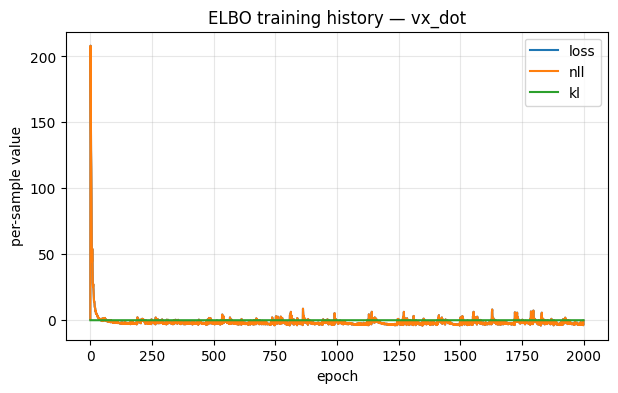

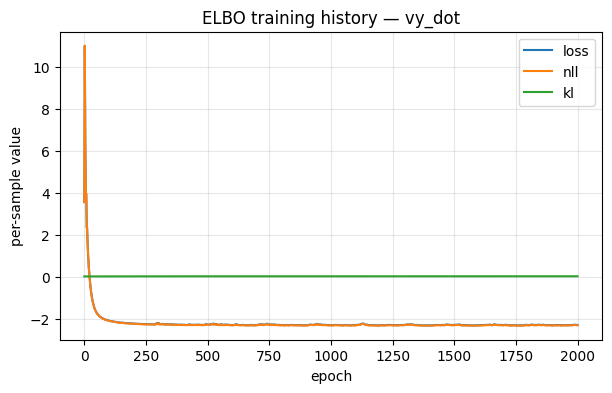

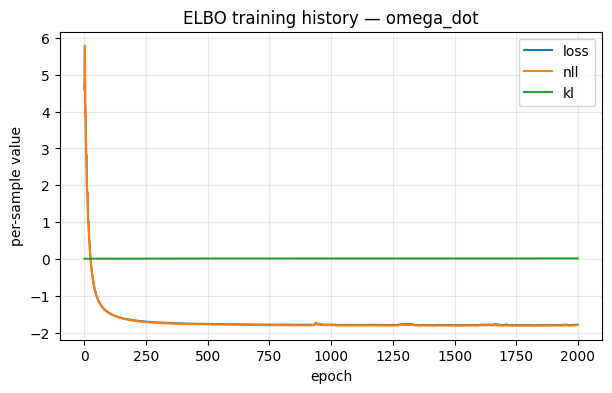

C:\Users\Admin\AppData\Local\Temp\ipykernel_19160\2752452908.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(B, labels=labels, showfliers=False)


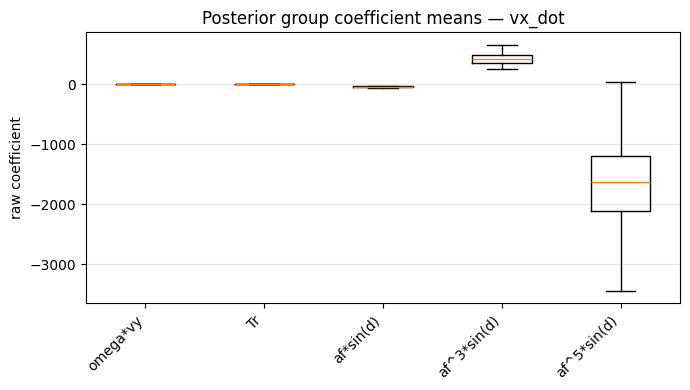

C:\Users\Admin\AppData\Local\Temp\ipykernel_19160\2752452908.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(B, labels=labels, showfliers=False)


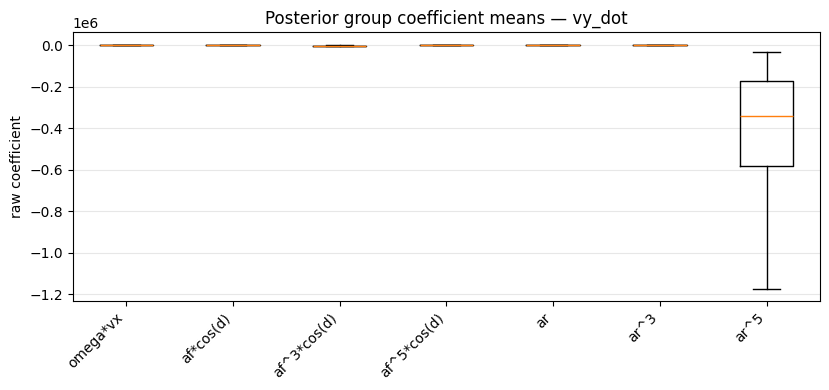

C:\Users\Admin\AppData\Local\Temp\ipykernel_19160\2752452908.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(B, labels=labels, showfliers=False)


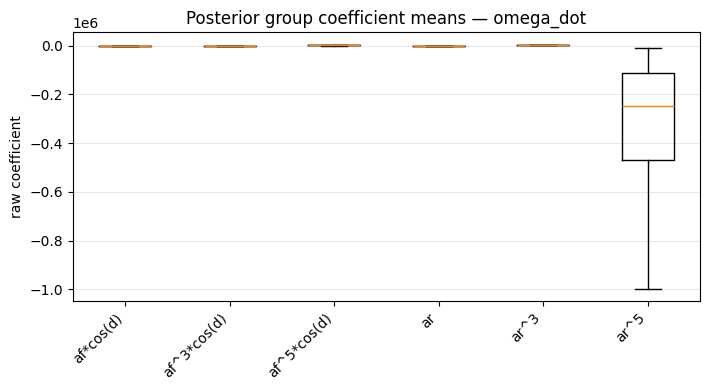

In [14]:
# ============================================================
# 13. Diagnostic plots
# ============================================================

# ELBO histories
for ch in channel_names:
    hist = history_by_channel[ch]
    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="loss")
    plt.plot(hist["nll"], label="nll")
    plt.plot(hist["kl"], label="kl")
    plt.xlabel("epoch")
    plt.ylabel("per-sample value")
    plt.title(f"ELBO training history — {ch}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Coefficient distributions across training groups.
for ch in channel_names:
    active_idx = active_idx_by_channel[ch]
    B = params_by_channel[ch]["group_mu_raw"][:, active_idx]
    labels = [terms[i] for i in active_idx]

    plt.figure(figsize=(max(7, 1.2 * len(labels)), 4))
    plt.boxplot(B, labels=labels, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("raw coefficient")
    plt.title(f"Posterior group coefficient means — {ch}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Tire curve uncertainty check

The tire-force-like polynomials should have physically reasonable shapes. This plot uses the coefficient distribution learned from training groups.

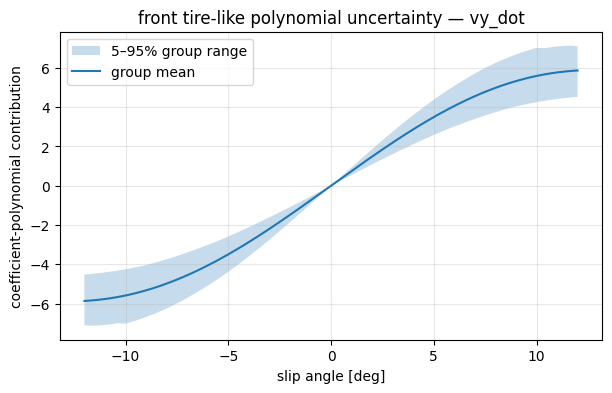

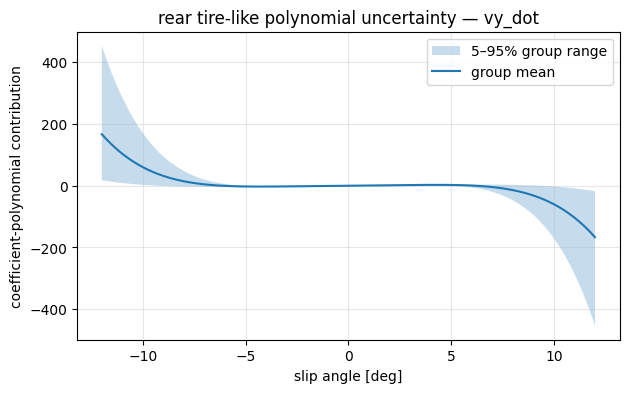

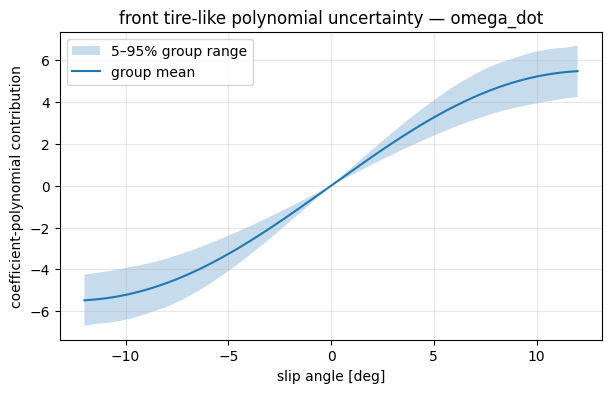

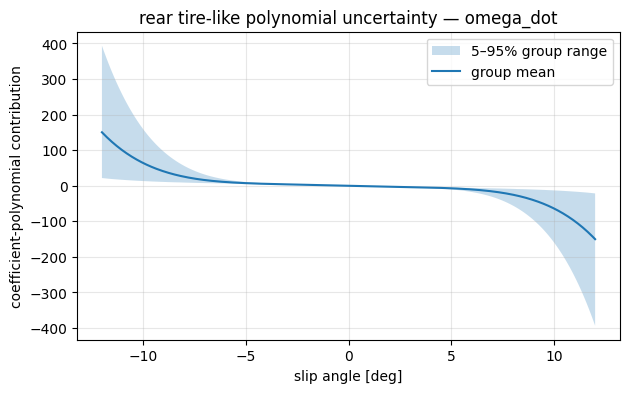

In [15]:
# ============================================================
# 14. Tire curve uncertainty check
# ============================================================

def tire_poly_from_coeff(coeff, slip_rad, channel, front=True):
    y = np.zeros_like(slip_rad)
    if front:
        # Use cos-projected terms to reconstruct lateral front force-like contribution.
        for term, power in [("af*cos(d)", 1), ("af^3*cos(d)", 3), ("af^5*cos(d)", 5)]:
            if term in term_to_idx:
                y += coeff[term_to_idx[term]] * slip_rad**power
    else:
        for term, power in [("ar", 1), ("ar^3", 3), ("ar^5", 5)]:
            if term in term_to_idx:
                y += coeff[term_to_idx[term]] * slip_rad**power
    return y

slip_deg = np.linspace(-12, 12, 400)
slip = np.deg2rad(slip_deg)

# Front/rear contributions in vy_dot units from vy_dot channel.
for ch, front in [("vy_dot", True), ("vy_dot", False), ("omega_dot", True), ("omega_dot", False)]:
    active_idx = active_idx_by_channel[ch]
    B = params_by_channel[ch]["group_mu_raw"]
    curves = []
    for i in range(B.shape[0]):
        curves.append(tire_poly_from_coeff(B[i], slip, ch, front=front))
    curves = np.vstack(curves)

    mean = np.mean(curves, axis=0)
    lo = np.percentile(curves, 5, axis=0)
    hi = np.percentile(curves, 95, axis=0)

    plt.figure(figsize=(7, 4))
    plt.fill_between(slip_deg, lo, hi, alpha=0.25, label="5–95% group range")
    plt.plot(slip_deg, mean, label="group mean")
    plt.xlabel("slip angle [deg]")
    plt.ylabel("coefficient-polynomial contribution")
    side = "front" if front else "rear"
    plt.title(f"{side} tire-like polynomial uncertainty — {ch}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 14b. Front and rear Pacejka comparison: learned variational model vs true variational model

This section creates **two separate figures**: one for the front tire and one for the rear tire.

Each figure overlays:

- the **learned variational VINDy tire contribution**, obtained from the group-wise posterior coefficient distribution in the $\dot v_y$ channel; and
- the **true variational Pacejka family**, obtained from the sampled data-generation parameters.

The plotted quantity is lateral acceleration contribution, i.e. approximately $F_y/M$ at $\delta=0$. This makes the learned $\dot v_y$ coefficients directly comparable to the true Pacejka force divided by mass.


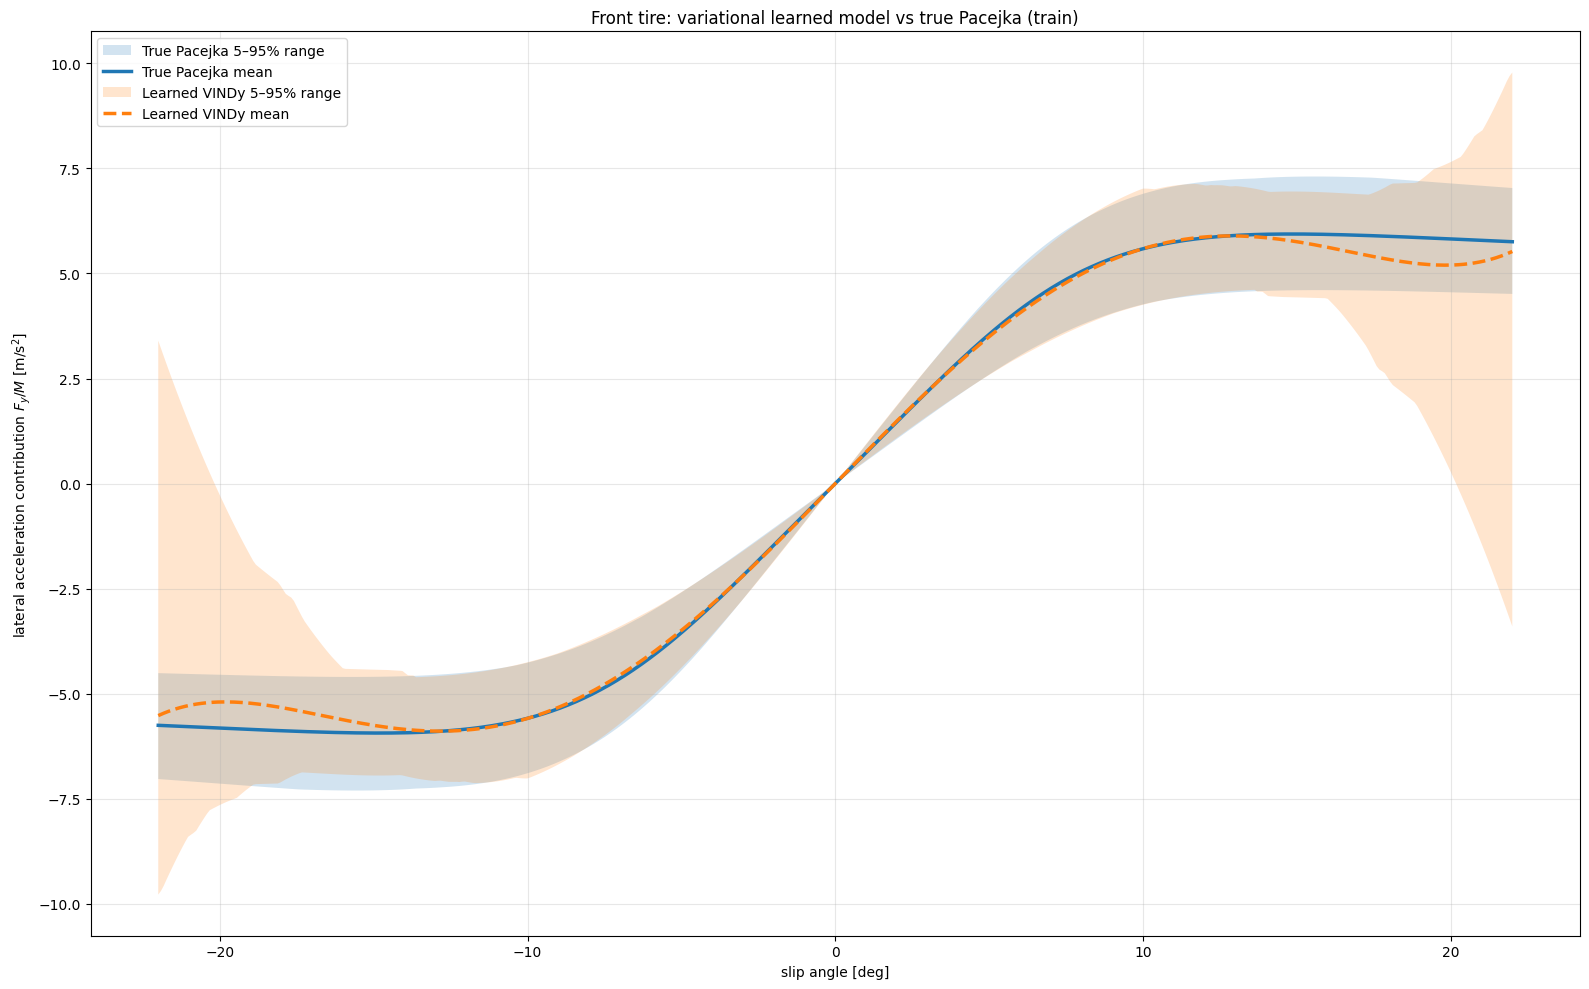

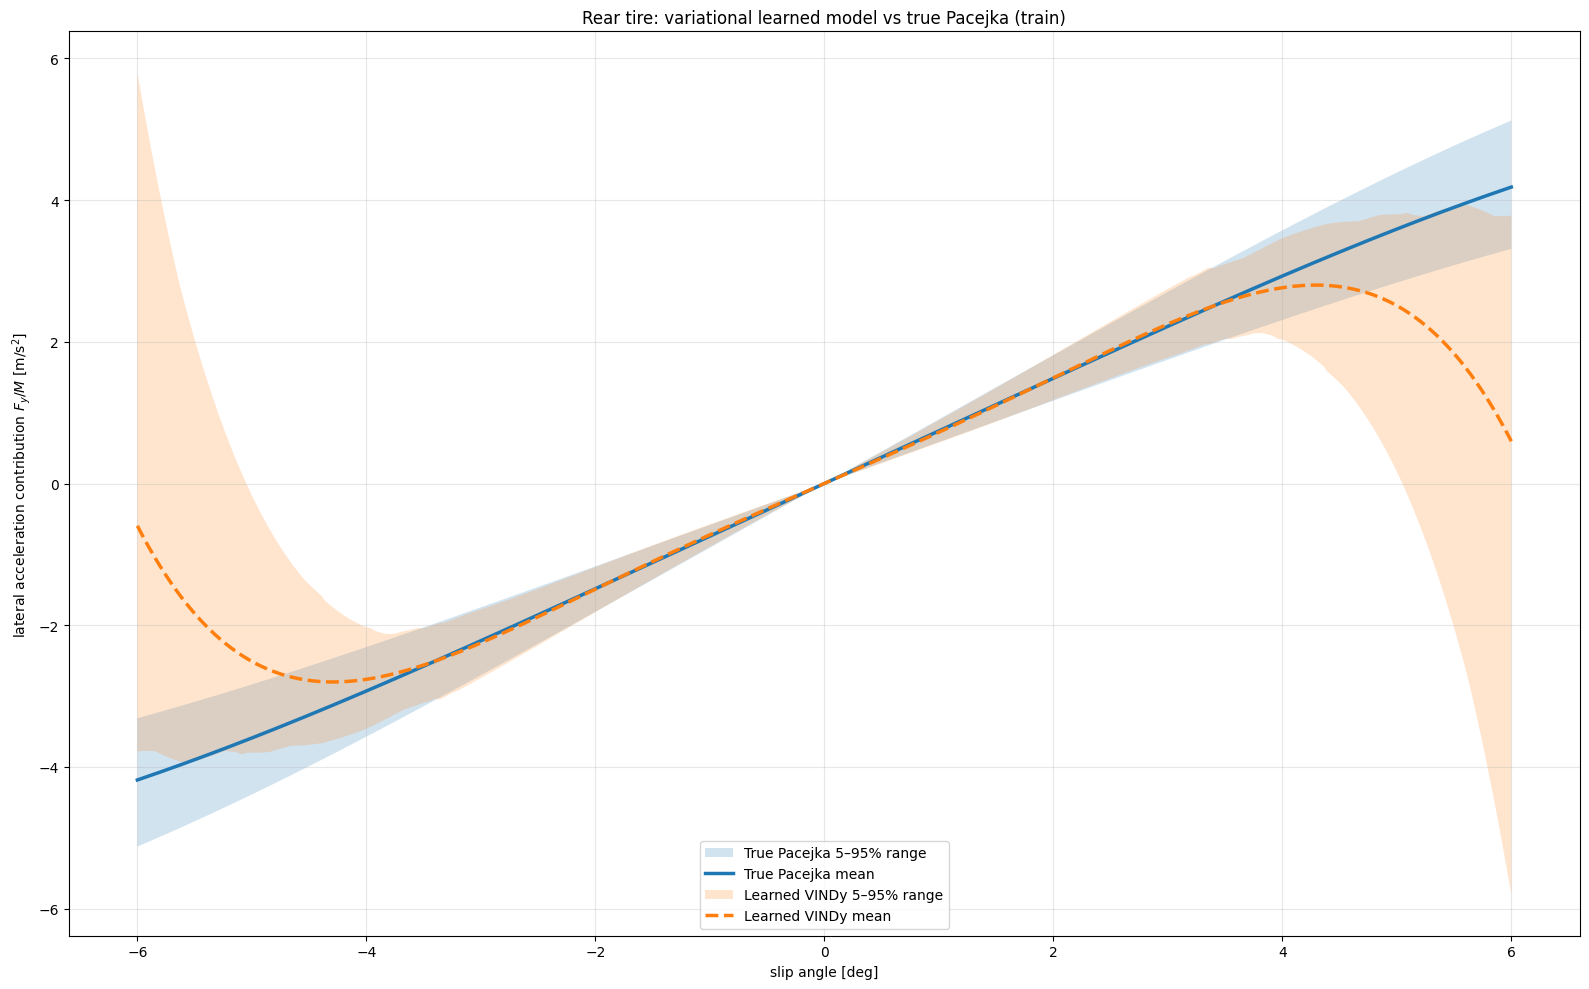

In [23]:
# ============================================================
# 14b. Front/rear Pacejka comparison:
#      learned variational VINDy model vs true variational model
# ============================================================

# This plot compares quantities in acceleration units, F_y / M [m/s^2].
# Why use the vy_dot channel?
#   vy_dot = -omega*vx + F_r/M + F_f*cos(delta)/M
# At delta ~= 0, the learned front cos-polynomial and rear polynomial
# are directly comparable to the true Pacejka curves divided by M.


def pacejka_np(alpha, B, C, D, E):
    """Pacejka magic formula used by the generator."""
    Ba = B * alpha
    return D * np.sin(C * np.arctan(Ba - E * (Ba - np.arctan(Ba))))


def extract_param_by_group(split, param_name, unique_groups):
    """
    Returns true parameter values ordered by unique_groups.

    Preferred data keys are like ptrain_B_f, ptrain_M, etc.
    This assumes the group id is a parameter-realization id.
    """
    candidate_keys = [
        f"p{split}_{param_name}",      # original/rich generator convention
        f"{split}_{param_name}",       # fallback convention
        f"{split}_p_{param_name}",
    ]

    key = None
    for k in candidate_keys:
        if k in data.files:
            key = k
            break

    if key is None:
        raise KeyError(
            f"Could not find parameter '{param_name}' for split='{split}'. "
            f"Tried keys: {candidate_keys}"
        )

    arr = np.asarray(data[key]).squeeze()

    # Case 1: parameter array already ordered exactly like unique_groups.
    if len(arr) == len(unique_groups):
        return arr.astype(float)

    # Case 2: group IDs are integer indices into parameter arrays.
    out = []
    for g in unique_groups:
        gi = int(g)
        if gi < 0 or gi >= len(arr):
            raise IndexError(
                f"Group id {gi} is outside parameter array '{key}' of length {len(arr)}. "
                "Use train_param_id as the group key or save per-group parameters explicitly."
            )
        out.append(arr[gi])

    return np.asarray(out, dtype=float)


def learned_tire_curves_from_vy(channel, side, slip_rad, include_group_posterior_std=False, n_samples_per_group=1, seed=42):
    """
    Learned variational VINDy tire curves from the vy_dot channel.

    side='front' uses af*cos(d), af^3*cos(d), af^5*cos(d).
    side='rear' uses ar, ar^3, ar^5.
    """
    rng = np.random.default_rng(seed)

    if channel != "vy_dot":
        raise ValueError("For direct F_y/M comparison, use channel='vy_dot'.")

    if side == "front":
        basis = [("af*cos(d)", 1), ("af^3*cos(d)", 3), ("af^5*cos(d)", 5)]
    elif side == "rear":
        basis = [("ar", 1), ("ar^3", 3), ("ar^5", 5)]
    else:
        raise ValueError("side must be 'front' or 'rear'")

    group_mu = params_by_channel[channel]["group_mu_raw"]
    group_std = params_by_channel[channel]["group_std_raw"]

    curves = []
    for g in range(group_mu.shape[0]):
        for _ in range(n_samples_per_group):
            if include_group_posterior_std:
                coeff = rng.normal(group_mu[g], group_std[g])
            else:
                coeff = group_mu[g]

            y = np.zeros_like(slip_rad)
            for term, power in basis:
                idx = term_to_idx[term]
                y += coeff[idx] * slip_rad**power
            curves.append(y)

    return np.vstack(curves)


def true_pacejka_curves(split, side, unique_groups, slip_rad):
    """
    True variational Pacejka family from the data-generation parameters.
    Returns curves in F_y/M units [m/s^2].
    """
    M = extract_param_by_group(split, "M", unique_groups)

    if side == "front":
        B = extract_param_by_group(split, "B_f", unique_groups)
        C = extract_param_by_group(split, "C_f", unique_groups)
        D = extract_param_by_group(split, "D_f", unique_groups)
        E = extract_param_by_group(split, "E_f", unique_groups)
    elif side == "rear":
        B = extract_param_by_group(split, "B_r", unique_groups)
        C = extract_param_by_group(split, "C_r", unique_groups)
        D = extract_param_by_group(split, "D_r", unique_groups)
        E = extract_param_by_group(split, "E_r", unique_groups)
    else:
        raise ValueError("side must be 'front' or 'rear'")

    curves = []
    for Bi, Ci, Di, Ei, Mi in zip(B, C, D, E, M):
        Fy = pacejka_np(slip_rad, Bi, Ci, Di, Ei)
        curves.append(Fy / Mi)

    return np.vstack(curves)


def band_stats(curves, low=5, high=95):
    return {
        "mean": np.mean(curves, axis=0),
        "lo": np.percentile(curves, low, axis=0),
        "hi": np.percentile(curves, high, axis=0),
    }


def plot_learned_vs_true_pacejka(side, split="train", slip_deg_min=-22, slip_deg_max=22):
    """
    Creates one figure for either front or rear tire.
    """
    slip_deg = np.linspace(slip_deg_min, slip_deg_max, 500)
    slip_rad = np.deg2rad(slip_deg)

    if split == "train":
        unique_groups = train_unique_groups
    elif split == "val":
        unique_groups = val_unique_groups
    elif split == "test":
        unique_groups = test_unique_groups
    else:
        raise ValueError("split must be 'train', 'val', or 'test'")

    learned_curves = learned_tire_curves_from_vy(
        channel="vy_dot",
        side=side,
        slip_rad=slip_rad,
        include_group_posterior_std=False,   # set True to include q_r posterior width too
        n_samples_per_group=1,
        seed=SEED,
    )
    true_curves = true_pacejka_curves(
        split=split,
        side=side,
        unique_groups=unique_groups,
        slip_rad=slip_rad,
    )

    L = band_stats(learned_curves)
    T = band_stats(true_curves)

    plt.figure(figsize=(16, 10))

    # True variational Pacejka family
    plt.fill_between(
        slip_deg, T["lo"], T["hi"],
        alpha=0.20,
        label="True Pacejka 5–95% range"
    )
    plt.plot(
        slip_deg, T["mean"],
        linewidth=2.5,
        label="True Pacejka mean"
    )

    # Learned variational VINDy family
    plt.fill_between(
        slip_deg, L["lo"], L["hi"],
        alpha=0.20,
        label="Learned VINDy 5–95% range"
    )
    plt.plot(
        slip_deg, L["mean"],
        linewidth=2.5,
        linestyle="--",
        label="Learned VINDy mean"
    )

    title_side = "Front" if side == "front" else "Rear"
    plt.title(f"{title_side} tire: variational learned model vs true Pacejka ({split})")
    plt.xlabel("slip angle [deg]")
    plt.ylabel(r"lateral acceleration contribution $F_y/M$ [m/s$^2$]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Two images:
plot_learned_vs_true_pacejka(side="front", split="train", slip_deg_min=-22, slip_deg_max=22)
plot_learned_vs_true_pacejka(side="rear", split="train", slip_deg_min=-6, slip_deg_max=6)


## 15. Export model for SMPC

For SMPC, use **joint group-consistent sampling**: sample one group index and take the coefficient realization for all channels from that same group. This avoids constructing fake vehicles by mixing longitudinal coefficients from one realization with yaw coefficients from another.

In [17]:
# ============================================================
# 15. Export model and sampling helpers
# ============================================================

EXPORT_PATH = Path("hierarchical_elbo_vindy_model.npz")

save_dict = {
    "terms": np.array(terms, dtype=object),
    "channel_names": np.array(channel_names, dtype=object),
    "theta_scale": theta_scale,
    "y_scale": y_scale,
    "train_group_ids": train_unique_groups,
}

for j, ch in enumerate(channel_names):
    key = ch
    save_dict[f"{key}_active_idx"] = active_idx_by_channel[ch]
    save_dict[f"{key}_group_mu_raw"] = params_by_channel[ch]["group_mu_raw"]
    save_dict[f"{key}_group_std_raw"] = params_by_channel[ch]["group_std_raw"]
    save_dict[f"{key}_global_mu_raw"] = params_by_channel[ch]["global_mu_raw"]
    save_dict[f"{key}_global_std_raw"] = params_by_channel[ch]["global_std_raw"]
    save_dict[f"{key}_sigma_eps_raw"] = np.array(params_by_channel[ch]["sigma_eps_raw"])

np.savez(EXPORT_PATH, **save_dict)
print("Saved:", EXPORT_PATH.resolve())


def sample_joint_group_consistent_model(rng=None, use_posterior_std=True):
    """
    Sample one physically consistent VINDy model for SMPC.

    One training group index is chosen, then all channels use coefficients
    from that same group. This preserves cross-channel parameter consistency.
    """
    if rng is None:
        rng = np.random.default_rng()

    G = len(train_unique_groups)
    gi = rng.integers(0, G)

    xi = {}
    for ch in channel_names:
        mu = params_by_channel[ch]["group_mu_raw"][gi].copy()
        if use_posterior_std:
            std = params_by_channel[ch]["group_std_raw"][gi]
            xi[ch] = rng.normal(mu, std)
        else:
            xi[ch] = mu

    return xi, train_unique_groups[gi]


# Example sampled model
rng = np.random.default_rng(123)
xi_sample, group_id = sample_joint_group_consistent_model(rng=rng, use_posterior_std=True)
print("Sampled group:", group_id)
for ch in channel_names:
    print("\n", ch)
    for idx in active_idx_by_channel[ch]:
        print(f"  {terms[idx]:20s}: {xi_sample[ch][idx]:+12.6f}")

Saved: C:\VS\hierarchical_elbo_vindy_model.npz
Sampled group: 1

 vx_dot
  omega*vy            :    +0.981162
  Tr                  :    +0.002430
  af*sin(d)           :   -49.377866
  af^3*sin(d)         :  +452.206649
  af^5*sin(d)         : -1742.249367

 vy_dot
  omega*vx            :    -0.998344
  af*cos(d)           :   +48.578356
  af^3*cos(d)         :  -414.908149
  af^5*cos(d)         : +1507.136032
  ar                  :   +45.792399
  ar^3                : +1991.346888
  ar^5                : -350736.105500

 omega_dot
  af*cos(d)           :   +46.710907
  af^3*cos(d)         :  -399.559690
  af^5*cos(d)         : +1452.663150
  ar                  :   -82.075923
  ar^3                : +1821.568058
  ar^5                : -267632.244911


## 16. Minimal rollout/simulation hook for SMPC

This is not the full SMPC optimizer yet. It is the model-evaluation function that an SMPC solver would call for each sampled scenario.

In [18]:
# ============================================================
# 16. Minimal VINDy dynamics function for scenario rollout
# ============================================================

def compute_slip_angles_simple(vx, vy, omega, delta, lf=1.015, lr=1.895):
    """
    Same basic convention as the generator; adjust if your deployment model uses different lf/lr.
    """
    vy_front = vy + omega * lf
    v_lat_w = vy_front * np.cos(delta) - vx * np.sin(delta)
    v_lon_w = vx * np.cos(delta) + vy_front * np.sin(delta)
    af = -np.arctan2(v_lat_w, max(abs(v_lon_w), 0.5))
    ar = -np.arctan2(vy - omega * lr, max(abs(vx), 0.5))
    return af, ar


def theta_row_from_state_input(x, u, lf=1.015, lr=1.895):
    """
    x = [vx, vy, omega]
    u = [delta, Tr]
    returns one raw Theta row with 17 terms.
    """
    vx, vy, omega = x
    delta, Tr = u
    af, ar = compute_slip_angles_simple(vx, vy, omega, delta, lf=lf, lr=lr)
    s = np.sin(delta)
    c = np.cos(delta)

    return np.array([
        omega * vy,
        omega * vx,
        vx,
        vy,
        Tr,
        delta,
        af * s,
        af * c,
        af**3 * s,
        af**3 * c,
        af**5 * s,
        af**5 * c,
        ar,
        ar**3,
        ar**5,
        vx * af * c,
        vx * ar,
    ], dtype=float)


def vindy_rhs(x, u, xi_model, lf=1.015, lr=1.895):
    """
    Continuous-time RHS using one sampled VINDy model.
    Returns [vx_dot, vy_dot, omega_dot].
    """
    th = theta_row_from_state_input(x, u, lf=lf, lr=lr)
    return np.array([
        th @ xi_model["vx_dot"],
        th @ xi_model["vy_dot"],
        th @ xi_model["omega_dot"],
    ])


def euler_step_vindy(x, u, xi_model, dt=0.03):
    return np.asarray(x) + dt * vindy_rhs(x, u, xi_model)

# Example one-step rollout
x0 = np.array([20.0, 0.2, 0.05])
u0 = np.array([5.0*np.pi/180.0, 1000.0])
xi_model, gid = sample_joint_group_consistent_model(rng=np.random.default_rng(7))
x1 = euler_step_vindy(x0, u0, xi_model, dt=0.03)
print("x0:", x0)
print("u0:", u0)
print("sampled group:", gid)
print("x1:", x1)

x0: [20.    0.2   0.05]
u0: [8.72664626e-02 1.00000000e+03]
sampled group: 113
x1: [20.0586385   0.26321194  0.15606478]
